# 8.0 Sigma Sweep Test Run
Testing sigma sweep code with sigma = 0.5 for all four models. Results include    
a) learned vs latent pseudotime could be plotted for each model.  
b) learned vs latent z space could be plotted for each model.  

## Import modules

In [1]:
import sys
sys.path.insert(0, "/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation")

from sigma_sweep import rho_for_run

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scvi/__init__.py:31: DeprecationWarning: scvi is deprecated, please uninstall scvi via `pip uninstall scvi` and install the new scvi-tools package at github.com/YosefLab/scvi-tools
  warnings.warn(deprecation_msg, DeprecationWarning)


## Test Run for Base Decipher
Testing vanilla Decipher at sigma=0.5, seed=0, decipher_seed=1

Epoch 114 (batch 24/24) | | train elbo: 33.34 (last epoch: 33.61) | val ll: 44.03:  11%|█▏        | 114/1000 [00:31<04:04,  3.63it/s]2026-07-20 02:21:10,912 | INFO : Early stopping has been triggered.
2026-07-20 02:21:10,915 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-20 02:21:10,915 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-20 02:21:10,919 | INFO : Saving decipher model with run_id 2026-07-20-02-21-10-finite-purple-soda.


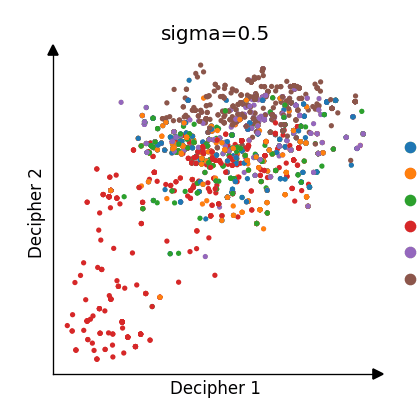

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-20 02:21:11,230 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-20 02:21:11,230 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
2026-07-20 02:21:13,738 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/native-decipher/decipher/tools/trajectory_inference.py:225: FutureWarning: In the future, the default backend for 

rho = 0.9359
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/0720_vz_0.06_-0.07_0.32_0.05_-0.27.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/trained/decipher/sigma0.5_seed0_decipher.h5ad


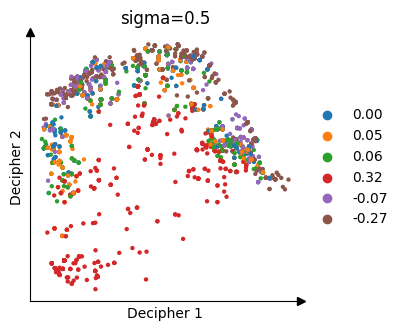

In [2]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, model="decipher", decipher_seed=1)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

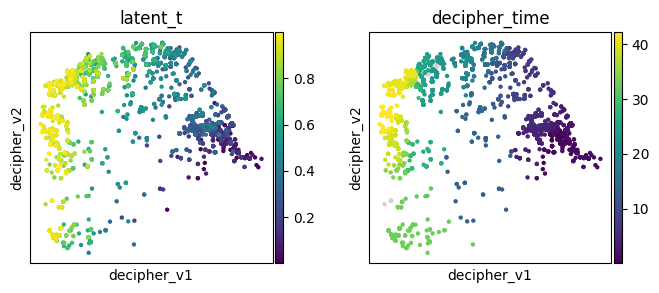

rho = 0.9359


In [3]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.0203
sigma=0.5  learned decipher_z silhouette (by batch) = -0.0205


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:521: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


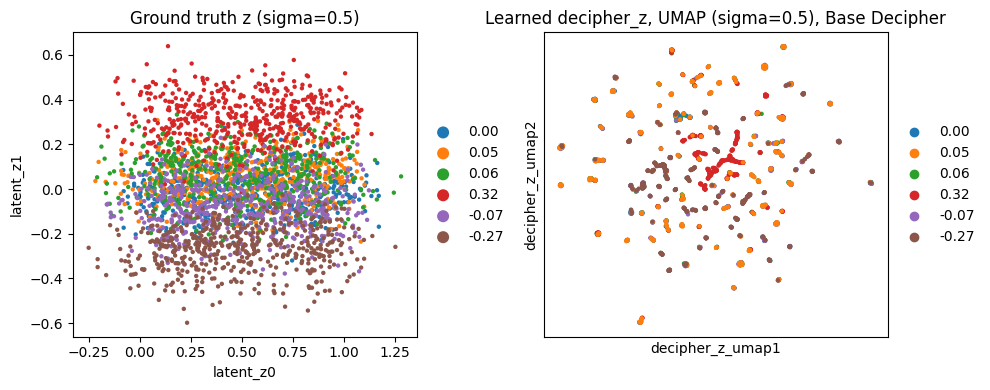

In [4]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: ground truth z (already 2D) vs. UMAP of learned decipher_z ---
sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
              ax=axes[0], show=False, title=f"Ground truth z (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z, UMAP (sigma={0.5}), Base Decipher")
plt.tight_layout()
plt.show()

## Test Run for Decipher-vz
Testing decipher_vz (batch conditioning for z along decoder) at sigma=0.5, seed=0, decipher_seed=1

Epoch 96 (batch 24/24) | | train elbo: 34.03 (last epoch: 33.99) | val ll: 43.49:  10%|▉         | 96/1000 [00:27<04:15,  3.54it/s]2026-07-20 02:21:46,968 | INFO : Early stopping has been triggered.
2026-07-20 02:21:46,971 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-20 02:21:46,971 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-20 02:21:46,972 | INFO : Saving decipher model with run_id 2026-07-20-02-21-46-kinetic-cyan-distance.


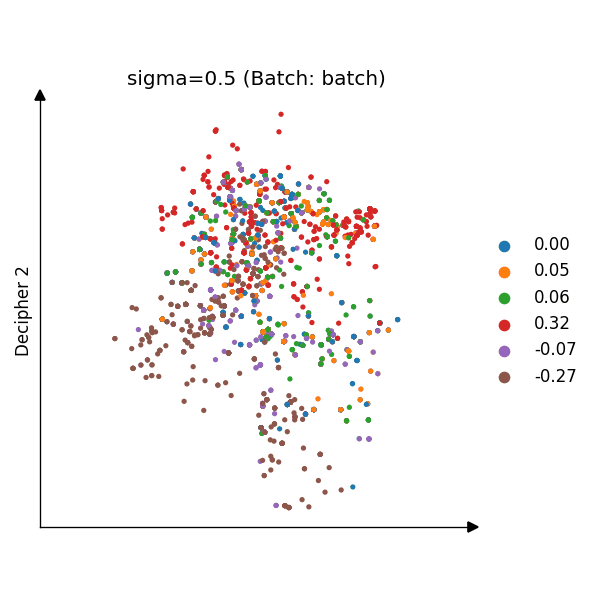

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-20 02:21:47,373 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-20 02:21:47,373 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
2026-07-20 02:21:47,405 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-20 02:21:47,583 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simula

rho = 0.9376
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/0720_vz_0.06_-0.07_0.32_0.05_-0.27.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/trained/decipher_vz/sigma0.5_seed0_decipher_vz.h5ad


In [5]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, model="decipher_vz", decipher_seed=1)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

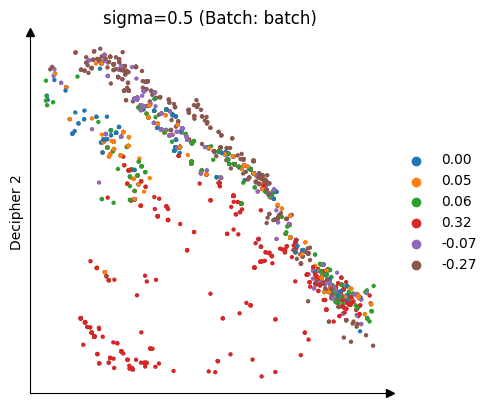

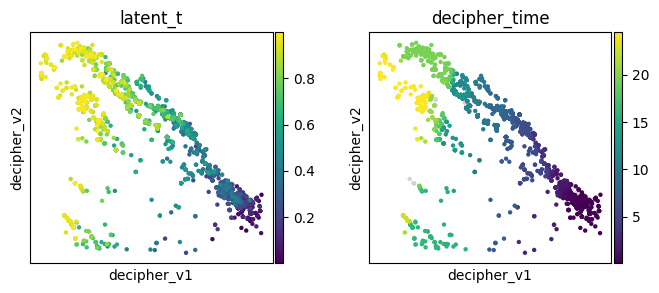

rho = 0.9376


In [6]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.0203
sigma=0.5  learned decipher_z silhouette (by batch) = 0.0026


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:521: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


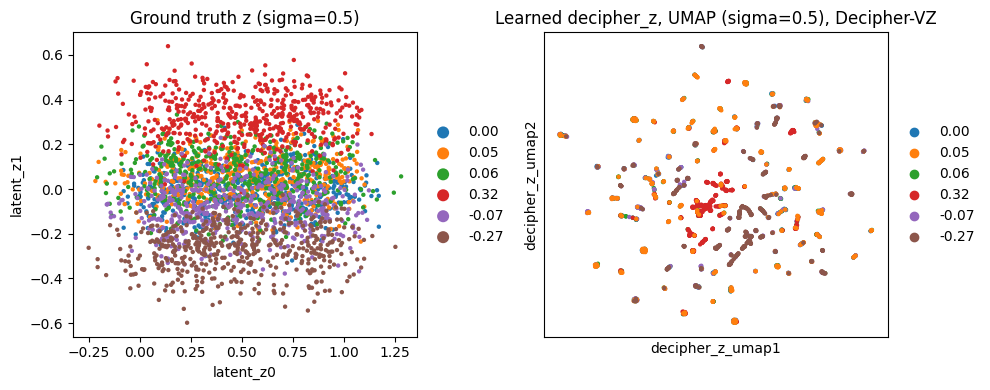

In [7]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: ground truth z (already 2D) vs. UMAP of learned decipher_z ---
sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
              ax=axes[0], show=False, title=f"Ground truth z (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z, UMAP (sigma={0.5}), Decipher-VZ")
plt.tight_layout()
plt.show()

## Test Run for Decipher-vz2
Testing decipher_vz2 (conditioning batch on z for encoder and decoder) at sigma=0.5, seed=0, decipher_seed=1

Epoch 82 (batch 24/24) | | train elbo: 34.31 (last epoch: 34.28) | val ll: 44.38:   8%|▊         | 82/1000 [00:24<04:31,  3.38it/s]2026-07-20 02:22:17,253 | INFO : Early stopping has been triggered.
2026-07-20 02:22:17,255 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-20 02:22:17,256 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-20 02:22:17,256 | INFO : Saving decipher model with run_id 2026-07-20-02-22-17-objective-camel-electric.


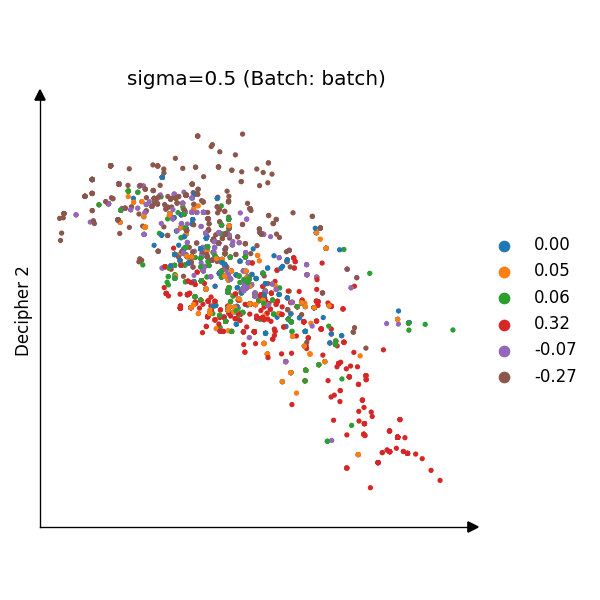

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-20 02:22:17,595 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-20 02:22:17,595 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
2026-07-20 02:22:17,627 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-20 02:22:17,850 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simula

rho = 0.9411
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/0720_vz_0.06_-0.07_0.32_0.05_-0.27.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/trained/decipher_vz2/sigma0.5_seed0_decipher_vz2.h5ad


In [8]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, model="decipher_vz2", decipher_seed=1)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

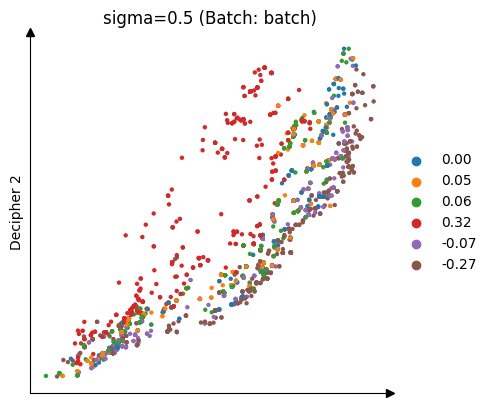

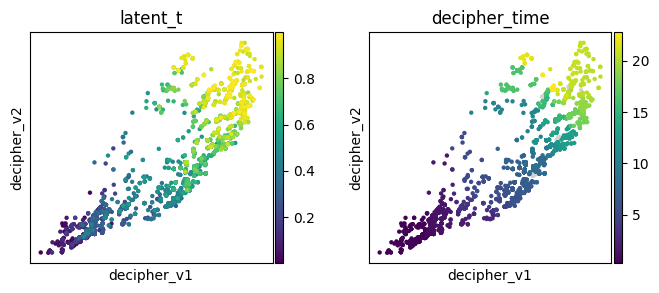

rho = 0.9411


In [9]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.0203
sigma=0.5  learned decipher_z silhouette (by batch) = -0.0225


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:521: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


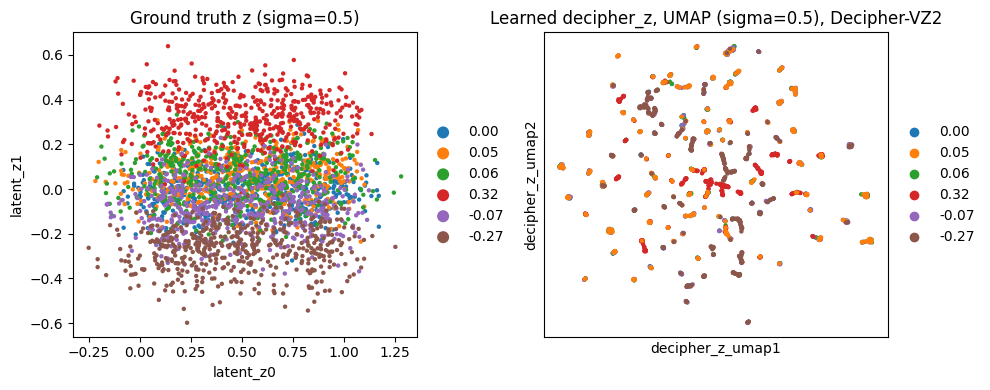

In [10]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: ground truth z (already 2D) vs. UMAP of learned decipher_z ---
sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
              ax=axes[0], show=False, title=f"Ground truth z (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z, UMAP (sigma={0.5}), Decipher-VZ2")
plt.tight_layout()
plt.show()

## Test Run for Decipher-mf
testing decipher_mf (mean field inference) at sigma=0.5, seed=0, decipher_seed=1

Epoch 251 (batch 24/24) | | train elbo: 35.97 (last epoch: 35.84) | val ll: 38.92:  25%|██▌       | 251/1000 [01:13<03:37,  3.44it/s]2026-07-20 02:23:36,972 | INFO : Early stopping has been triggered.
2026-07-20 02:23:36,975 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-20 02:23:36,975 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-20 02:23:36,976 | INFO : Saving decipher model with run_id 2026-07-20-02-23-36-resolving-upbeat-eggs.


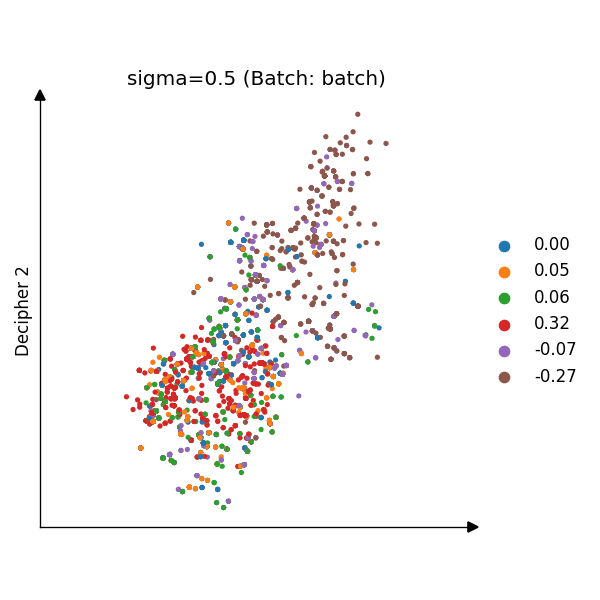

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
2026-07-20 02:23:37,939 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-20 02:23:37,939 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
2026-07-20 02:23:37,980 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-20 02:23:38,170 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simula

rho = 0.9299
ground truth: /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/0720_vz_0.06_-0.07_0.32_0.05_-0.27.h5ad
trained:      /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data/Simulated Data/Simulated Data Generation/../Simulated Adata/v-to-z/trained/decipher_mf/sigma0.5_seed0_decipher_mf.h5ad


In [11]:
rho, gt_path, trained_path, adata = rho_for_run(sigma=0.5, seed=0, model="decipher_mf", decipher_seed=1)
print(f"rho = {rho:.4f}")
print(f"ground truth: {gt_path}")
print(f"trained:      {trained_path}")

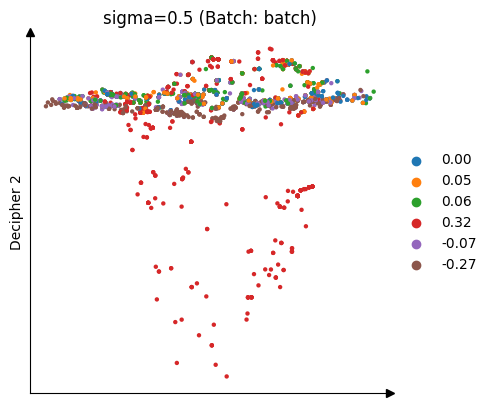

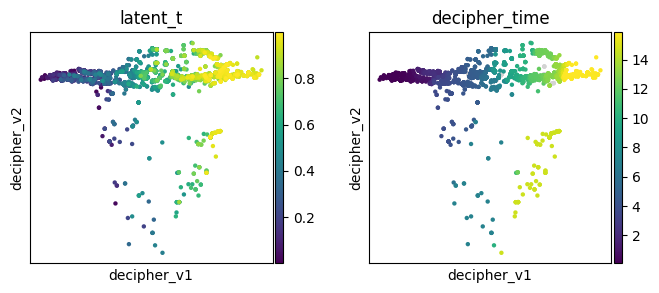

rho = 0.9299


In [12]:
import scanpy as sc

sc.pl.embedding(adata, basis="decipher_v", color=["latent_t", "decipher_time"])
print(f"rho = {rho:.4f}")

sigma=0.5  ground truth z silhouette (by batch) = 0.0203
sigma=0.5  learned decipher_z silhouette (by batch) = -0.0590


/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:521: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


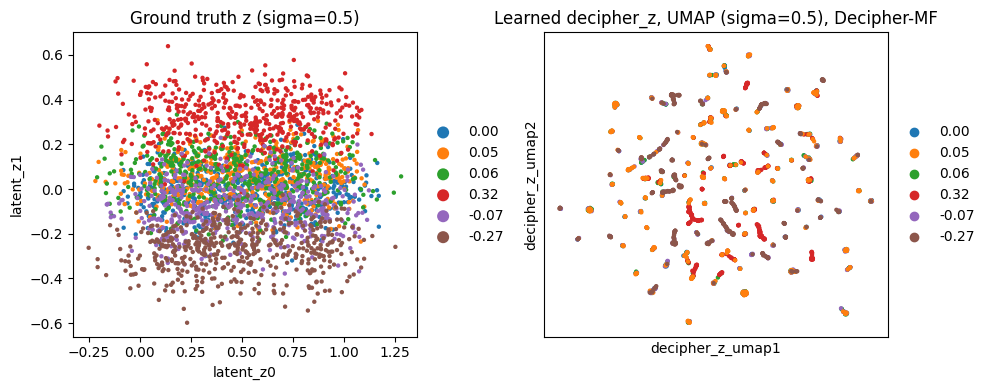

In [13]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# --- Quantitative: silhouette score directly on raw feature space (no projection) ---
batch_labels = adata.obs["batch"].astype(str)

sil_ground_truth = silhouette_score(
    adata.obs[["latent_z0", "latent_z1"]].values, batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
sil_learned = silhouette_score(
    adata.obsm["decipher_z"], batch_labels,
    sample_size=min(5000, adata.n_obs), random_state=42,
)
print(f"sigma={0.5}  ground truth z silhouette (by batch) = {sil_ground_truth:.4f}")
print(f"sigma={0.5}  learned decipher_z silhouette (by batch) = {sil_learned:.4f}")

# --- Qualitative: ground truth z (already 2D) vs. UMAP of learned decipher_z ---
sc.pp.neighbors(adata, use_rep="decipher_z", random_state=42)
sc.tl.umap(adata, random_state=42)
adata.obsm["decipher_z_umap"] = adata.obsm["X_umap"]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
sc.pl.scatter(adata, x="latent_z0", y="latent_z1", color="batch",
              ax=axes[0], show=False, title=f"Ground truth z (sigma={0.5})")
sc.pl.embedding(adata, basis="decipher_z_umap", color="batch",
                ax=axes[1], show=False, title=f"Learned decipher_z, UMAP (sigma={0.5}), Decipher-MF")
plt.tight_layout()
plt.show()